<a href="https://colab.research.google.com/github/kit2824bcs068/pepper-leaf-disease-detection/blob/main/Paperpublicationfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
# Import All Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
import seaborn as sns

print("✅ All Libraries Imported Successfully!")
print("TensorFlow version:", tf.__version__)

✅ All Libraries Imported Successfully!
TensorFlow version: 2.19.0


In [ ]:
# Dataset Paths
train_dir = '/content/drive/MyDrive/dataset/train'
val_dir   = '/content/drive/MyDrive/dataset/val'

# Image Settings
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 10

# Data Augmentation
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)
val_gen = ImageDataGenerator(rescale=1./255)

# Load Data
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("✅ Dataset Loaded!")
print("Classes:", train_data.class_indices)
print("Train images:", train_data.samples)
print("Val images:", val_data.samples)

Found 1915 images belonging to 2 classes.
Found 855 images belonging to 2 classes.
✅ Dataset Loaded!
Classes: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1}
Train images: 1915
Val images: 855


In [ ]:
# ============================================
# MODEL 1: MobileNetV2
# ============================================
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ MobileNetV2 Model Built!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ MobileNetV2 Model Built!


In [ ]:
# ============================================
# TRAIN MODEL 1: MobileNetV2
# ============================================
print("🚀 Training MobileNetV2...")

history_mobilenet = mobilenet_model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data
)

mobilenet_model.save('/content/drive/MyDrive/mobilenet_pepper.h5')
print("✅ MobileNetV2 Trained and Saved!")

# Print Final Accuracy
mob_acc = max(history_mobilenet.history['val_accuracy']) * 100
print(f"MobileNetV2 Best Accuracy: {mob_acc:.2f}%")

🚀 Training MobileNetV2...
Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 445s 7s/step - accuracy: 0.5885 - loss: 0.8137 - val_accuracy: 0.5977 - val_loss: 0.6613
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.6862 - loss: 0.5933 - val_accuracy: 0.6982 - val_loss: 0.5406
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.7645 - loss: 0.4819 - val_accuracy: 0.8047 - val_loss: 0.4342
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.8026 - loss: 0.4183 - val_accuracy: 0.8292 - val_loss: 0.3932
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.8428 - loss: 0.3673 - val_accuracy: 0.8784 - val_loss: 0.3312
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8658 - loss: 0.3219 - val_accuracy: 0.8807 - val_loss: 0.3169
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8679 - loss: 0.3155 - val_accuracy: 0.8655 - val_loss: 0.3266
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.8794 - loss: 0.2844 

✅ MobileNetV2 Trained and Saved!
MobileNetV2 Best Accuracy: 92.40%


In [ ]:
# ============================================
# MODEL 2: VGG16
# ============================================
train_data.reset()
val_data.reset()

base_vgg = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_vgg.trainable = False

x = base_vgg.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

vgg_model = Model(inputs=base_vgg.input, outputs=output)

vgg_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("🚀 Training VGG16...")
history_vgg = vgg_model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data
)

vgg_model.save('/content/drive/MyDrive/vgg16_pepper.keras')
print("✅ VGG16 Trained and Saved!")

vgg_acc = max(history_vgg.history['val_accuracy']) * 100
print(f"VGG16 Best Accuracy: {vgg_acc:.2f}%")


🚀 Training VGG16...
Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1565s 26s/step - accuracy: 0.7828 - loss: 0.4514 - val_accuracy: 0.8924 - val_loss: 0.2708
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1557s 26s/step - accuracy: 0.8590 - loss: 0.3102 - val_accuracy: 0.8936 - val_loss: 0.2690
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1558s 26s/step - accuracy: 0.8721 - loss: 0.2983 - val_accuracy: 0.8971 - val_loss: 0.2506
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1607s 26s/step - accuracy: 0.8966 - loss: 0.2571 - val_accuracy: 0.9099 - val_loss: 0.2154
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1561s 26s/step - accuracy: 0.9023 - loss: 0.2459 - val_accuracy: 0.9380 - val_loss: 0.1831
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1569s 26s/step - accuracy: 0.9091 - loss: 0.2368 - val_accuracy: 0.9415 - val_loss: 0.1794
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1555s 26s/step - accuracy: 0.9185 - loss: 0.2164 - val_accuracy: 0.9368 - val_loss: 0.1941
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1593s 27s/step - accuracy: 0.9185 - los

In [ ]:
# ============================================
# MODEL 3: ResNet50
# ============================================
train_data.reset()
val_data.reset()

base_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_resnet.trainable = False

x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

resnet_model = Model(inputs=base_resnet.input, outputs=output)

resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training ResNet50...")
history_resnet = resnet_model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data
)

resnet_model.save('/content/drive/MyDrive/resnet50_pepper.h5')
print("✅ ResNet50 Model Saved!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training ResNet50...
Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 569s 9s/step - accuracy: 0.4836 - loss: 0.9109 - val_accuracy: 0.3240 - val_loss: 0.7012
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 497s 8s/step - accuracy: 0.4956 - loss: 0.7997 - val_accuracy: 0.3977 - val_loss: 0.7053
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 491s 8s/step - accuracy: 0.5029 - loss: 0.7811 - val_accuracy: 0.4047 - val_loss: 0.7106
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 488s 8s/step - accuracy: 0.5086 - loss: 0.7645 - val_accuracy: 0.4105 - val_loss: 0.6969
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 488s 8s/step - accuracy: 0.4987 - loss: 0.7644 - val_accuracy: 0.4070 - val_loss: 0.6970
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 486s 8s/step - accuracy: 0.5044 - loss: 0.7471 - val_accuracy: 0.5158 - val_loss: 0.6880
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 487s 8s/step - accuracy: 0.5117 - loss: 0.7325 - val_accuracy: 0.4058 - val_loss: 0.6967
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 4

✅ ResNet50 Model Saved!


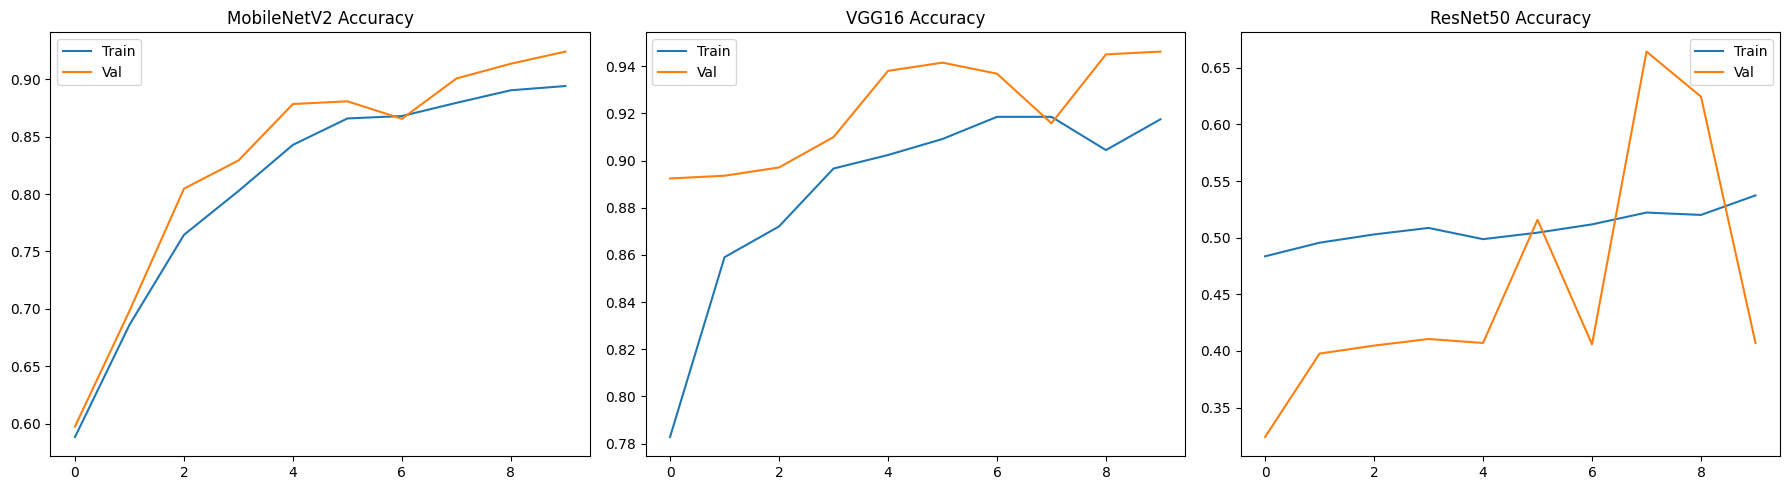


========== MODEL COMPARISON ==========
MobileNetV2 Accuracy : 92.40%
VGG16 Accuracy       : 94.62%
ResNet50 Accuracy    : 66.43%
Best Model           : VGG16


In [ ]:
# ============================================
# PLOT ACCURACY COMPARISON
# ============================================
plt.figure(figsize=(18, 5))

# MobileNetV2
plt.subplot(1, 3, 1)
plt.plot(history_mobilenet.history['accuracy'], label='Train')
plt.plot(history_mobilenet.history['val_accuracy'], label='Val')
plt.title('MobileNetV2 Accuracy')
plt.legend()

# VGG16
plt.subplot(1, 3, 2)
plt.plot(history_vgg.history['accuracy'], label='Train')
plt.plot(history_vgg.history['val_accuracy'], label='Val')
plt.title('VGG16 Accuracy')
plt.legend()

# ResNet50
plt.subplot(1, 3, 3)
plt.plot(history_resnet.history['accuracy'], label='Train')
plt.plot(history_resnet.history['val_accuracy'], label='Val')
plt.title('ResNet50 Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/accuracy_comparison.png')
plt.show()

# Final Accuracy Comparison Table
mob_acc = max(history_mobilenet.history['val_accuracy']) * 100
vgg_acc = max(history_vgg.history['val_accuracy']) * 100
res_acc = max(history_resnet.history['val_accuracy']) * 100

print("\n========== MODEL COMPARISON ==========")
print(f"MobileNetV2 Accuracy : {mob_acc:.2f}%")
print(f"VGG16 Accuracy       : {vgg_acc:.2f}%")
print(f"ResNet50 Accuracy    : {res_acc:.2f}%")
print(f"Best Model           : {'MobileNetV2' if mob_acc > vgg_acc and mob_acc > res_acc else 'VGG16' if vgg_acc > res_acc else 'ResNet50'}")
print("=======================================")

In [ ]:
# ============================================
# CLASSIFICATION REPORT (Best Model)
# ============================================
from sklearn.metrics import classification_report

val_data.reset()
predictions = mobilenet_model.predict(val_data)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_data.classes
class_labels = list(val_data.class_indices.keys())

print("\nClassification Report - MobileNetV2:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

27/27 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step

Classification Report - MobileNetV2:
                              precision    recall  f1-score   support

Pepper__bell__Bacterial_spot       0.38      0.42      0.40       346
       Pepper__bell__healthy       0.58      0.53      0.55       509

                    accuracy                           0.49       855
                   macro avg       0.48      0.48      0.48       855
                weighted avg       0.50      0.49      0.49       855



In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive Mounted!")

Mounted at /content/drive
✅ Drive Mounted!


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load saved VGG16 model
vgg_model = load_model('/content/drive/MyDrive/vgg16_pepper.keras')
print("✅ VGG16 Model Loaded!")

✅ VGG16 Model Loaded!


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
import tensorflow as tf

def generate_gradcam(model, img_array, layer_name='block5_conv3'):
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), predictions.numpy()

print("✅ Grad-CAM function ready!")

✅ Grad-CAM function ready!


Saving Pepper-Plant-Leaf-Spot.jpg to Pepper-Plant-Leaf-Spot.jpg

🔍 Prediction : Pepper__bell__Bacterial_spot
📊 Confidence : 100.00%


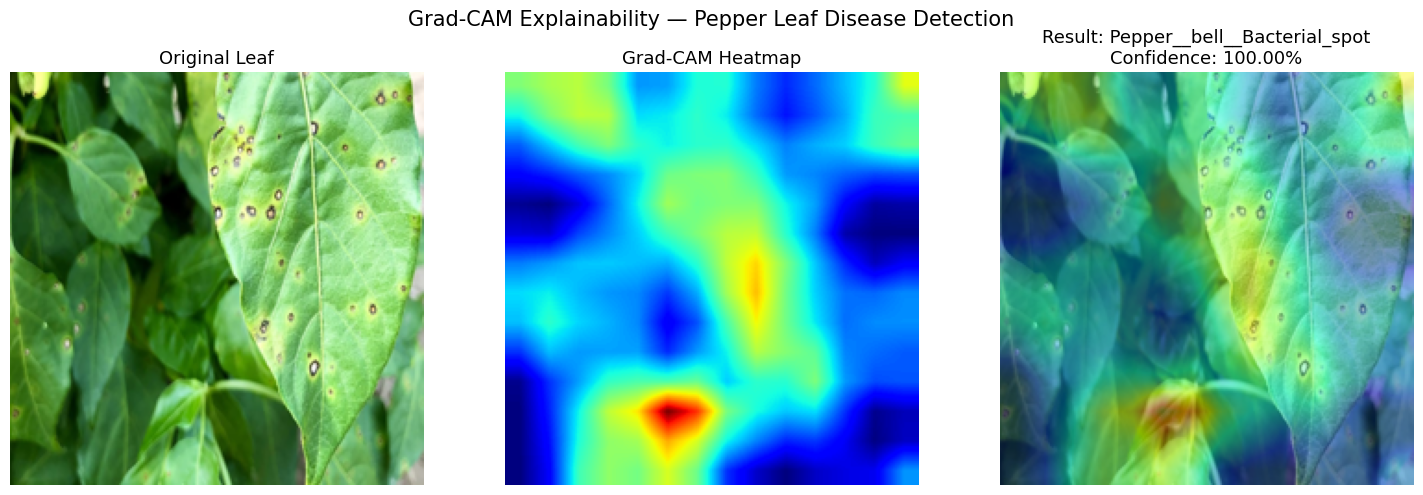

✅ Grad-CAM result saved to Drive!


In [ ]:
from google.colab import files
from PIL import Image
import io

# Upload your pepper leaf image
uploaded = files.upload()
img_filename = list(uploaded.keys())[0]

# Preprocess
IMG_SIZE = 224
img = Image.open(io.BytesIO(uploaded[img_filename])).convert('RGB')
img_resized = img.resize((IMG_SIZE, IMG_SIZE))
img_array = np.array(img_resized) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Class labels
class_labels = ['Pepper__bell__Bacterial_spot', 'Pepper__bell__healthy']

# Generate Grad-CAM
heatmap, predictions = generate_gradcam(vgg_model, img_array)

# Get prediction
pred_class = np.argmax(predictions[0])
confidence = predictions[0][pred_class] * 100
label = class_labels[pred_class]

print(f"\n🔍 Prediction : {label}")
print(f"📊 Confidence : {confidence:.2f}%")

# Overlay heatmap on original image
heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
heatmap_colored = cv2.applyColorMap(
    np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
)
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
original = np.array(img_resized)
superimposed = cv2.addWeighted(original, 0.6, heatmap_colored, 0.4, 0)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original)
axes[0].set_title('Original Leaf', fontsize=13)
axes[0].axis('off')

axes[1].imshow(heatmap_resized, cmap='jet')
axes[1].set_title('Grad-CAM Heatmap', fontsize=13)
axes[1].axis('off')

axes[2].imshow(superimposed)
axes[2].set_title(f'Result: {label}\nConfidence: {confidence:.2f}%', fontsize=13)
axes[2].axis('off')

plt.suptitle('Grad-CAM Explainability — Pepper Leaf Disease Detection', fontsize=15)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gradcam_result.png', dpi=150)
plt.show()
print("✅ Grad-CAM result saved to Drive!")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Settings
IMG_SIZE = 224
BATCH_SIZE = 32

# Reload val_data
val_dir = '/content/drive/MyDrive/dataset/val'
val_gen = ImageDataGenerator(rescale=1./255)
val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Important!
)

# Reload VGG16 model
vgg_model = load_model('/content/drive/MyDrive/vgg16_pepper.keras')

print("✅ val_data and VGG16 model reloaded!")
print("Classes:", val_data.class_indices)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 855 images belonging to 2 classes.
✅ val_data and VGG16 model reloaded!
Classes: {'Pepper__bell__Bacterial_spot': 0, 'Pepper__bell__healthy': 1}


27/27 ━━━━━━━━━━━━━━━━━━━━ 584s 21s/step


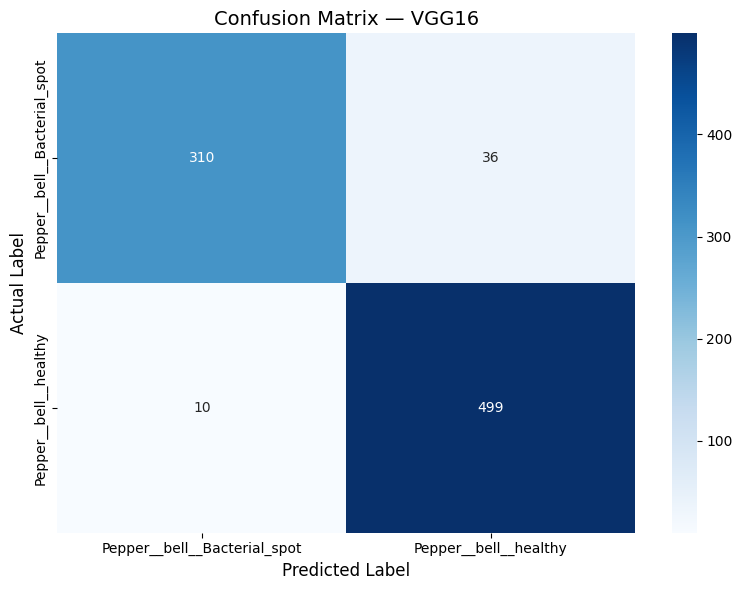

✅ Confusion Matrix saved to Drive!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Reset validation data
val_data.reset()

# Get predictions from VGG16
predictions_vgg = vgg_model.predict(val_data)
predicted_classes_vgg = np.argmax(predictions_vgg, axis=1)
true_classes = val_data.classes
class_labels = list(val_data.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes_vgg)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix — VGG16', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_vgg16.png', dpi=150)
plt.show()
print("✅ Confusion Matrix saved to Drive!")

In [ ]:
from sklearn.metrics import classification_report

print("\nClassification Report — VGG16 (Best Model):")
print(classification_report(true_classes, predicted_classes_vgg,
                            target_names=class_labels))


Classification Report — VGG16 (Best Model):
                              precision    recall  f1-score   support

Pepper__bell__Bacterial_spot       0.97      0.90      0.93       346
       Pepper__bell__healthy       0.93      0.98      0.96       509

                    accuracy                           0.95       855
                   macro avg       0.95      0.94      0.94       855
                weighted avg       0.95      0.95      0.95       855

